正在处理数据集：10x-Multiome-Pbmc10k
✅ 数据集10x-Multiome-Pbmc10k处理完成

正在处理数据集：D25
✅ 数据集D25处理完成

正在处理数据集：D31
✅ 数据集D31处理完成

正在处理数据集：Muto-2021
✅ 数据集Muto-2021处理完成



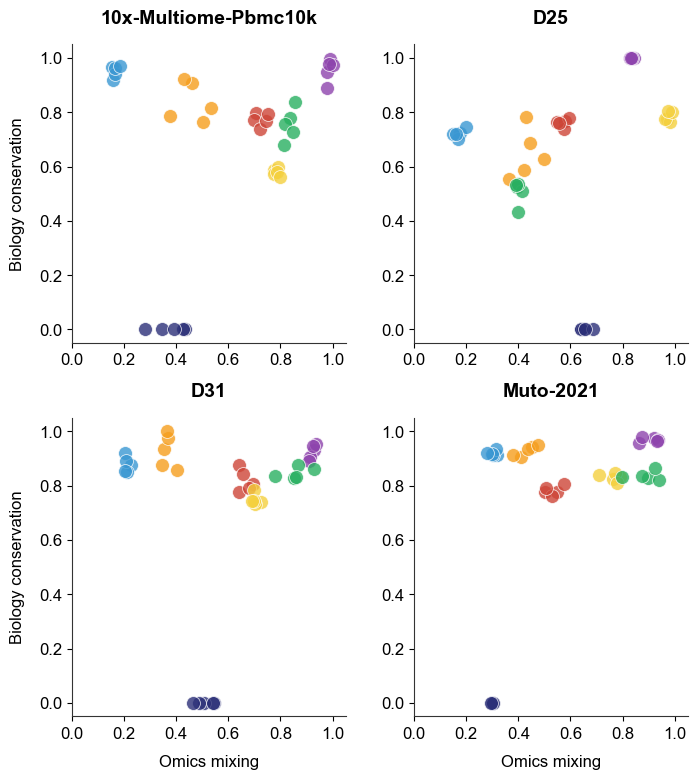


方法-颜色对应表：
- UniDISA: #8E44AD
- MaxFuse: #CD4537
- scConfluence: #F59E1D
- BindSC: #F4D03E
- GLUE: #28AF60
- Seurat: #3A97D2
- Uniport: #2C3078


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns  # 导入seaborn用于样式设置
from matplotlib.lines import Line2D

# =====================================================
# 1. 应用用户指定的样式设置（优先执行，确保全局生效）
# =====================================================
# seaborn样式：白色背景（无默认网格）
# sns.set(style='white')

# 字号配置（用户指定）
TINY_SIZE = 12
SMALL_SIZE = 12
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

# 应用matplotlib字体大小配置
plt.rc('font', size=TINY_SIZE)          # 全局默认字号
plt.rc('axes', titlesize=BIGGER_SIZE)   # 子图标题字号
plt.rc('axes', labelsize=MEDIUM_SIZE)   # x/y轴标签字号
plt.rc('xtick', labelsize=TINY_SIZE)    # x轴刻度字号
plt.rc('ytick', labelsize=TINY_SIZE)    # y轴刻度字号
plt.rc('legend', fontsize=MEDIUM_SIZE)  # 图例字号
plt.rc('figure', titlesize=BIGGER_SIZE) # 整体图标题字号（若需）

# 字体家族：Arial（用户指定）
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['axes.unicode_minus'] = False  # 解决负号显示异常

# =====================================================
# 2. 核心函数（数据处理逻辑不变）
# =====================================================
def min_max_normalize(series):
    """min-max归一化（x∈[0,1]），处理max=min情况"""
    min_val, max_val = series.min(), series.max()
    return pd.Series(0.5, index=series.index) if max_val == min_val else (series - min_val) / (max_val - min_val)

def process_single_repeat(df, top8_indicators, category_to_indicators, METHOD_ORDER):
    """单轮repeat处理：筛选方法→归一化→算类别均值"""
    df_methods = df[df["Embedding"].isin(METHOD_ORDER)].reset_index(drop=True)
    # 前8指标归一化
    normalized = df_methods[["Embedding"]].copy()
    for ind in top8_indicators:
        normalized[ind] = min_max_normalize(df_methods[ind])
    # 类别均值计算
    cat_mean = normalized[["Embedding"]].copy()
    for cat, inds in category_to_indicators.items():
        cat_mean[f"{cat}（均值）"] = normalized[inds].mean(axis=1)
    return normalized, cat_mean

def process_dataset(file_path, N_REPEAT, top8_indicators, category_to_indicators, METHOD_ORDER):
    """完整数据集处理：循环repeat→合并→验证"""
    all_cat_mean = []
    for r in range(1, N_REPEAT + 1):
        df = pd.read_excel(file_path, sheet_name=f"repeat_{r}")
        _, cat_mean_df = process_single_repeat(df, top8_indicators, category_to_indicators, METHOD_ORDER)
        cat_mean_df["Repeat"] = r
        all_cat_mean.append(cat_mean_df)
        # 归一化验证
        norm_vals = process_single_repeat(df, top8_indicators, category_to_indicators, METHOD_ORDER)[0][top8_indicators].values
        assert (norm_vals >= 0).all() and (norm_vals <= 1.0001).all(), f"数据集{file_path}的repeat_{r}归一化异常"
    # 数据量验证
    combined_cat_mean = pd.concat(all_cat_mean, ignore_index=True)
    assert len(combined_cat_mean) == 35, f"数据集{file_path}数据量异常（预期35行，实际{len(combined_cat_mean)}行）"
    return combined_cat_mean

# =====================================================
# 3. 全局配置（4数据集路径+固定参数）
# =====================================================
# 关键：替换为你的4个数据集实际路径和名称！
datasets = [
    {
        "name": "10x-Multiome-Pbmc10k",  # 数据集1名称（子图标题）
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\10x-Multiome-Pbmc10k\bio_bc.xlsx"
    },
    {
        "name": "D25",   # 数据集2名称（需替换为实际名称）
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\D25\bio_bc.xlsx"
    },
    {
        "name": "D31",       # 数据集3名称（需替换为实际名称）
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\D31\bio_bc.xlsx"
    },
    {
        "name": "Muto-2021",     # 数据集4名称（需替换为实际名称）
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\Muto-2021\bio_bc.xlsx"
    }
]

# 通用参数（与数据结构匹配）
N_REPEAT = 5
METHOD_ORDER = ["UniDISA", "MaxFuse", "scConfluence", "BindSC", "GLUE", "Seurat", "Uniport"]
top8_indicators = [
    "Isolated labels", "KMeans NMI", "KMeans ARI", "cLISI",
    "BRAS", "iLISI", "KBET", "Graph connectivity"
]
category_to_indicators = {
    "Bio conservation": ["Isolated labels", "KMeans NMI", "KMeans ARI", "cLISI"],
    "Batch correction": ["BRAS", "iLISI", "KBET", "Graph connectivity"]
}

# 固定颜色面板（用户指定，不变）
fixed_color_palette = {
    'UniDISA':'#8E44AD' ,    # 紫色（突出）
    'MaxFuse': '#CD4537',    # 红色
    'scConfluence': '#F59E1D',# 橙色
    'BindSC': '#F4D03E',     # 黄色
    'GLUE': '#28AF60',       # 绿色
    'Seurat': '#3A97D2',     # 天蓝色
    'Uniport': '#2C3078'     # 深蓝色
}

# =====================================================
# 4. 批量处理4个数据集（带容错）
# =====================================================
dataset_results = []
for ds in datasets:
    print(f"正在处理数据集：{ds['name']}")
    try:
        combined_cat_mean = process_dataset(
            file_path=ds["file_path"],
            N_REPEAT=N_REPEAT,
            top8_indicators=top8_indicators,
            category_to_indicators=category_to_indicators,
            METHOD_ORDER=METHOD_ORDER
        )
        dataset_results.append({"name": ds["name"], "data": combined_cat_mean})
        print(f"✅ 数据集{ds['name']}处理完成\n")
    except Exception as e:
        print(f"❌ 数据集{ds['name']}处理失败：{str(e)}\n")

if not dataset_results:
    raise ValueError("所有数据集处理失败，请检查路径和数据格式！")

# =====================================================
# 5. 绘制2×2子图（应用新样式，去上右边框）
# =====================================================
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
axes = axes.flatten()  # 转为1维数组，方便循环

# 循环绘制每个数据集的子图
for idx, (ds_res, ax) in enumerate(zip(dataset_results, axes[:len(dataset_results)])):
    ds_name = ds_res["name"]
    ds_data = ds_res["data"]
    
    # 绘制散点（样式与颜色不变）
    for method in METHOD_ORDER:
        method_data = ds_data[ds_data["Embedding"] == method]
        ax.scatter(
            x=method_data["Batch correction（均值）"],
            y=method_data["Bio conservation（均值）"],
            color=fixed_color_palette[method], marker="o",
            s=100, alpha=0.8, edgecolor="white", linewidth=0.6, label=method
        )
    
    # 子图核心样式：去上右边框+白色背景（匹配sns.set(style='white')）
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')  # 左下边框深灰色，提升对比度
    ax.spines['bottom'].set_color('#333333')
    
    # 轴范围与刻度（统一，便于对比）
    ax.set_xlim(0, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    # 标题与标签（应用用户指定字号）
    ax.set_title(ds_name, fontweight="bold", pad=15)  # 字号由rcParams控制（BIGGER_SIZE=12）
    if idx % 2 == 0:  # 左列子图显y轴标签
        ax.set_ylabel("Biology conservation", labelpad=10)  # 字号：MEDIUM_SIZE=10
    if idx >= 2:       # 下排子图显x轴标签
        ax.set_xlabel("Omics mixing", labelpad=10)  # 字号：MEDIUM_SIZE=10

# 隐藏未使用的子图（若部分数据集处理失败）
for ax in axes[len(dataset_results):]:
    ax.axis("off")

# =====================================================
# 6. 全局图例（应用指定字号，修复参数）
# =====================================================
legend_elements = [
    Line2D(
        [0], [0], marker='o', color='w',  # 隐藏线，仅显标记
        markerfacecolor=fixed_color_palette[method],
        markersize=8,
        markeredgecolor='white',  # 正确参数，避免AttributeError
        markeredgewidth=0.6,
        label=method
    )
    for method in METHOD_ORDER
]

# 全局图例（字号由rcParams控制：MEDIUM_SIZE=10）
# fig.legend(
#     handles=legend_elements,
#     loc='center left',
#     bbox_to_anchor=(0.9, 0.8),  # 右侧中间位置
#     ncol=1,
#     framealpha=0.95,
#     edgecolor="lightgray",
#     title="Methods",
#     title_fontsize=MEDIUM_SIZE  # 图例标题字号
# )

# 调整子图间距，预留图例空间（避免拥挤）
plt.subplots_adjust(left=0.08, right=0.85, top=0.92, bottom=0.08, hspace=0.25, wspace=0.25)

plt.savefig(
    "Fig2a.jpg",
    dpi=500,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)
# 显示图表
plt.show()

# 输出颜色对照表（备查）
print("\n方法-颜色对应表：")
for m in METHOD_ORDER:
    print(f"- {m}: {fixed_color_palette[m]}")